<a href="https://colab.research.google.com/github/sagargoel072005/machine-learning/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[165349.2  162597.7  153441.51 144372.41 142107.34 131876.9  134615.46
 130298.13 120542.52 123334.88 101913.08 100671.96  93863.75  91992.39
 119943.24 114523.61  78013.11  94657.16  91749.16  86419.7   76253.86
  78389.47  73994.56  67532.53  77044.01  64664.71  75328.87  72107.6
  66051.52  65605.48  61994.48  61136.38  63408.86  55493.95  46426.07
  46014.02  28663.76  44069.95  20229.59  38558.51  28754.33  27892.92
  23640.93  15505.73  22177.74   1000.23   1315.46      0.      542.05
      0.  ]
[192261.83 191792.06 191050.39 182901.99 166187.94 156991.12 156122.51
 155752.6  152211.77 149759.96 146121.95 144259.4  141585.52 134307.35
 132602.65 129917.04 126992.93 125370.37 124266.9  122776.86 118474.03
 111313.02 110352.25 108733.99 108552.04 107404.34 105733.54 105008.31
 103282.38 101004.64  99937.59  97483.56  97427.84  96778.92  96712.8
  96479.51  90708.19  89949.14  81229.06  81005.76  78239.91  77798.83
  71498.49  69758.98  65200.33  64926.08  49490.75  42559.73  35673

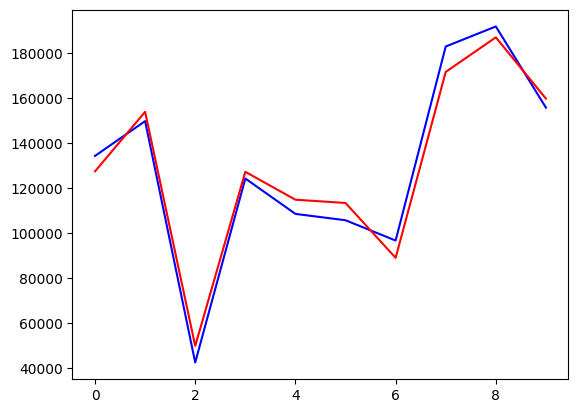

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sample_data/50_Startups.csv')
df.head(5)

#divide the data into dependent and independent variable
x = df.iloc[:,0].values
y = df.iloc[:,-1].values
print(x)
print(y)

#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

x_train = x_train.reshape(-1,1)
x_test = x_test.reshape(-1,1)

#feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

#create linear regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)

plt.plot(y_test,color='blue',label='test')
plt.plot(y_pred,color='red',label='prediction')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))
print("R2SC : ",r2_score(y_test,y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(y_test,y_pred)))


MAE :  6303.561064497747
MSE :  45084443.358964086
R2SC :  0.9742651057774813
RMSE :  6714.495018909768


[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 0.0 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 [67532

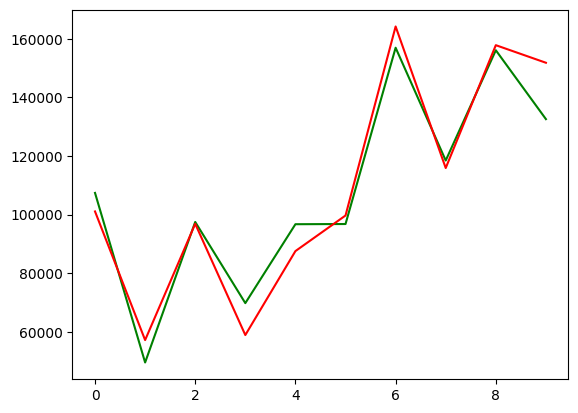

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sample_data/50_Startups.csv')
df.head(5)

#divide the data into dependent and independent variable
x = df.iloc[:,:-1].values
y = df.iloc[:,-1].values
print(x)
print(y)

#feature encoding - onehotencoder

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[3])],remainder='passthrough')
#'encoder' - Name of the transformer
# OneHotEncoder()-Method used to encode categorical data
# [3]	-Column index where the transformation will be applied
# passthrough → keep other columns unchanged

X = np.array(ct.fit_transform(x))
print(X)

# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

plt.plot(y_test,color='green',label='test')
plt.plot(y_pred,color='red',label='prediction')

MAE :  41.74526356832732
MSE :  3565.857157170491
R2SC :  0.5514794442912951
RMSE :  59.71479847718228


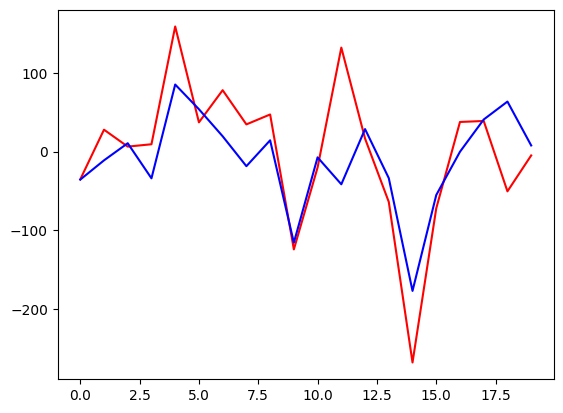

In [ ]:
# MULTIPLE LINEAR REGRESSION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px # advanced interactive graphs (3D etc.)
import plotly.graph_objects as go

from sklearn.datasets import make_regression # generates dummy regression dataset
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X,Y = make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)
df = pd.DataFrame({'feature1':X[0:,0],'feature2':X[0:,1],'target':Y})
df.head(5)

# n_samples=100 → 100 data points
# n_features=2 → 2 input variables (feature1, feature2)
# n_informative=2 → both features affect output
# n_targets=1 → single output
# noise=50 → adds randomness (real-world feel)


fig = px.scatter_3d(df,x='feature1',y='feature2',z='target')
fig.show()

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=3)

lr = LinearRegression()
lr.fit(X_train,Y_train)
y_pred = lr.predict(X_test)

print("MAE : ",mean_absolute_error(Y_test,y_pred))
print("MSE : ",mean_squared_error(Y_test,y_pred))
print("R2SC : ",r2_score(Y_test,y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(Y_test,y_pred)))

plt.plot(Y_test,color='red',label='test')
plt.plot(y_pred,color='blue',label='prediction')
plt.show()

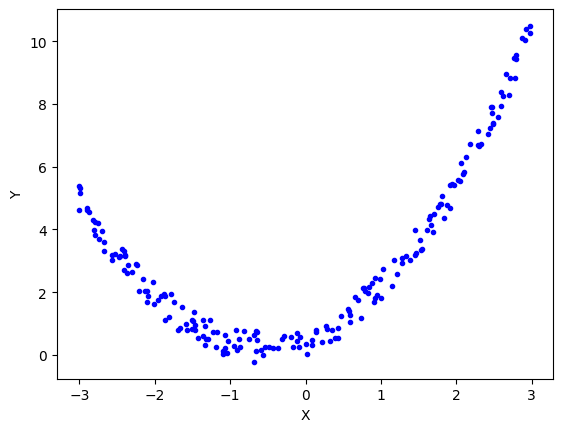

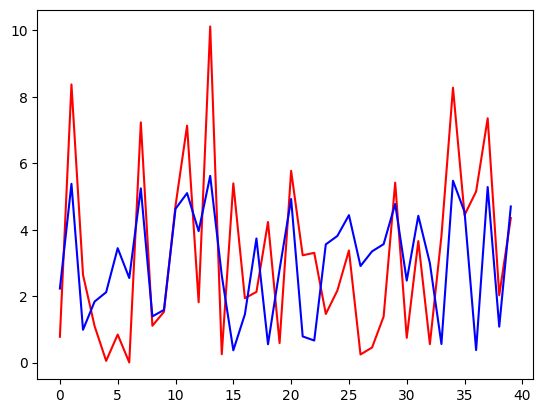

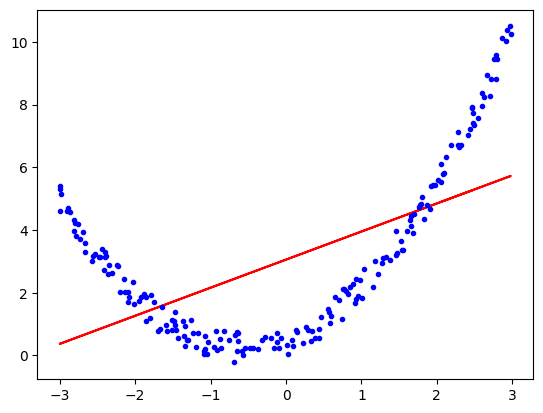

r2 score :  0.22501492998801143
[2.46365421]
[1.         2.46365421 6.06959209]
r2 score 2 :  0.983993524520512
coefficient :  [[0.         0.91259192 0.80409442]]
intercept :  [0.48753612]


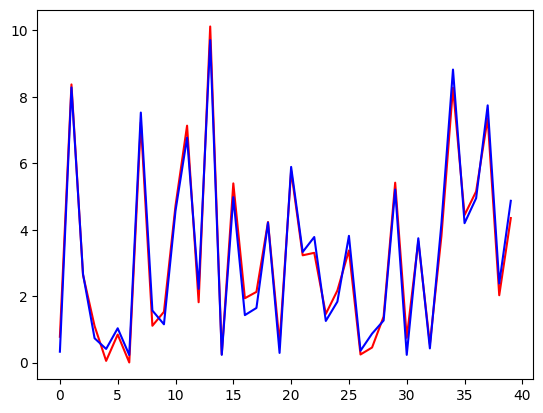

In [ ]:
# POLYNOMIAL REFRESSION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures , StandardScaler # → converts linear → polynomial features
from sklearn.pipeline import Pipeline # chain steps (scaling + model)

x = 6*np.random.rand(200,1)-3; # 6*(.) → scales to range 0 to 6 , -3 → shifts range to -3 to +3
y = 0.8*x**2 + 0.9*x + np.random.rand(200,1);
plt.plot(x,y,'b.')  # plt.scatter(x, y, color='blue')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

plt.plot(y_test,color='red',label='test')
plt.plot(y_pred,color='blue',label='prediction')
plt.show()

plt.plot(x_train,lr.predict(x_train),color='red')
plt.plot(x,y,'b.')
plt.show()

print("r2 score : ",r2_score(y_test,y_pred))

# APPLYING POLYNOMIAL LINEAR REGRESSION

poly = PolynomialFeatures(degree=2,include_bias=True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

print(x_train[0])
print(x_train_trans[0])

lr = LinearRegression()
lr.fit(x_train_trans,y_train)
y_pred1 = lr.predict(x_test_trans)

print("r2 score 2 : ",r2_score(y_test,y_pred1))
print("coefficient : ",lr.coef_)
print("intercept : ", lr.intercept_)
plt.plot(y_test,color='red',label='test')
plt.plot(y_pred1,color='blue',label='prediction')
plt.show()

r2 score 1 :  0.6026563210813484


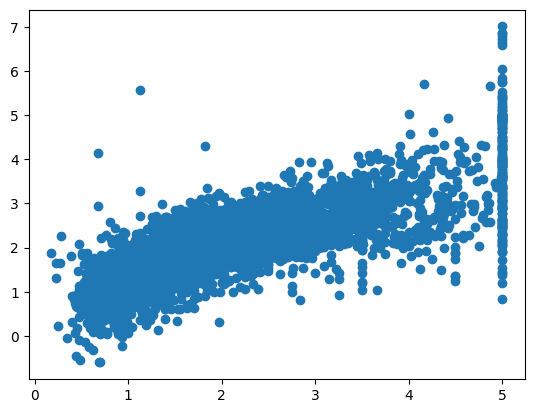

r2 score 2 :  0.6010784851494688


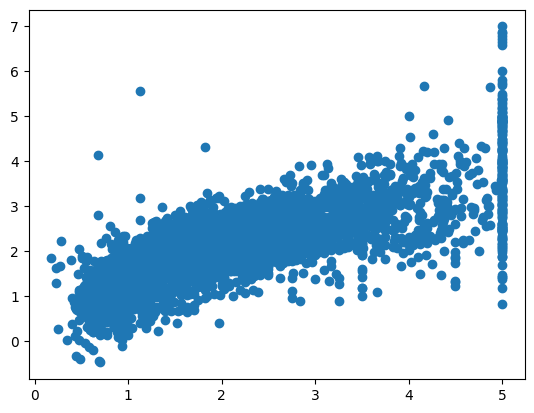

r2 score 3 :  -1.1269006543468407e-05


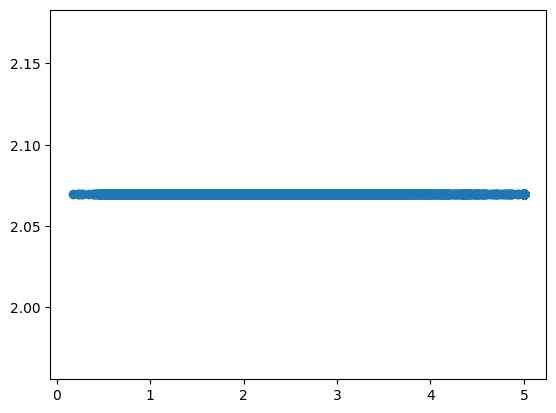

In [ ]:
# RIDGE AND LASSO REGRESSION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression ,Ridge,Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

# load the boston dataset

housing = fetch_california_housing()
data = pd.DataFrame(housing.data,columns=housing.feature_names)
target = pd.DataFrame(housing.target,columns=['target'])
df = pd.concat([data,target],axis=1)
df.head(5)
df.to_csv('california_housing.csv')

#split the data into features and target
x = df.drop('target',axis=1)
y = df['target']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
print("r2 score 1 : ",r2_score(y_test,y_pred))
# plt.plot(y_test,color='red',label='test')
# plt.plot(y_pred,color='blue',label='prediction')
plt.scatter(y_test,y_pred)
plt.show()

for a in [0.01, 0.1, 1, 10, 100]:
    ridge = Ridge(alpha=a)
    ridge.fit(x_train, y_train)
# ridge_model = Ridge(alpha=100)
# ridge_model.fit(x_train,y_train)
y_pred_ridge = ridge.predict(x_test)
print("r2 score 2 : ",r2_score(y_test,y_pred_ridge))
# plt.plot(y_test,color='red',label='test')
# plt.plot(y_pred_ridge,color='blue',label='prediction')
plt.scatter(y_test,y_pred_ridge)
plt.show()

for a in [0.001, 0.01, 0.1, 1]:
    lasso = Lasso(alpha=a)
    lasso.fit(x_train, y_train)

# lasso_model = Lasso(alpha=10)
# lasso_model.fit(x_train,y_train)
y_pred_lasso = lasso.predict(x_test)
print("r2 score 3 : ",r2_score(y_test,y_pred_lasso))
# q
plt.scatter(y_test,y_pred_lasso)
plt.show()

In [ ]:
# LOGISTIC REGRESSION

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

data = {
    'Age':[22,25,18,45,12,43,23,33],
    'Gender':['F','F','M','M','F','M','M','M'],
    'Smoker':['N','S','S','N','S','S','S','S'],
    'Disease':[1,1,0,0,0,1,0,1]
}
df = pd.DataFrame(data)
df = pd.get_dummies(df,columns=['Gender','Smoker'], drop_first=True)
# print(df.head())

X = df.drop('Disease',axis=1)
Y = df['Disease']

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)
model = LogisticRegression()
model.fit(x_train,y_train)

# regression coefficient and intercept
coef = model.coef_[0]
intercept = model.intercept_[0]

y_pred=model.predict(x_test)

print("regression coefficient : ",coef) # z = w1*Age + w2*Gender_M + w3*Smoker_S + b
print("intercept : ",intercept)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

regression coefficient :  [ 0.47725271 -0.569117   -0.38722737]
intercept :  -10.04045269779883
Accuracy: 0.5
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
